# Notebook 03 — Word2Vec: Representaciones Estáticas
**Proyecto 2 | Análisis Semántico de Letras Musicales**  
**Curso:** Minería de Textos — CUC  

---
## Objetivo
Entrenar modelos Word2Vec (CBOW y Skip-Gram) sobre el corpus musical,
explorar campos semánticos por género, realizar analogías vectoriales
y calcular similitud coseno entre géneros.


## 0. Dependencias

In [1]:
!pip install -q gensim scikit-learn matplotlib seaborn numpy pandas pymongo python-dotenv
print("Dependencias listas")

Dependencias listas



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Cargar corpus desde MongoDB

In [2]:
import sys
sys.path.append("..")

from src.database.MongoConnection import MongoConnection
from src.entities.consultar_base_datos import consultar_base_datos

cargador = consultar_base_datos()
cargador.cargar_todas()
df = cargador.df

print(f"Canciones cargadas: {len(df):,}")
print(f"Géneros disponibles: {df['genero'].unique()}")
print(f"Idiomas: {df['idioma'].value_counts().to_dict()}")
df.head(3)

Conectado a MongoDB Atlas: analisisMusical
Canciones cargadas: 6,940
Géneros disponibles: <StringArray>
[               'pop',    'alternative pop',              'k pop',
            'hip hop',   'alternative rock',          'dance pop',
                 'rb',         'electronic',                'rap',
   'contemporary r b',           'pop rock',          'synth pop',
               'rock',  'offizielle charts',           'folk pop',
    'unreleased song',          'indie pop',               'jazz',
            'soul rb',     'alternative rb',                'aor',
               'soul',    'contemporary rb',       'missing isrc',
            'dfw rap', 'west coast hip hop',        'hip hop rap',
        'self titled',           'rap rock',            'pop rap',
         'soundtrack',              'disco',         'euro house',
             'comedy',               'trap',        'rap hip hop',
      'billboard hot',       'tempo change',   'misleading title',
         'foreignrap',   

,id,titulo,artista,genero,anio,letra,idioma,fuente,url_fuente,fecha_recopilacion,metricas_num_palabras,metricas_densidad_lexica,metricas_ratio_sust_verbos,pos_tags_nltk,pos_tags_spacy,embeddings_word2vec_avg,embeddings_beto_cls
0,69c39f3480581b88ccabedc8,"​thank u, next",Ariana Grande,pop,2018,thought i'd end up with sean but he wasn't a m...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,463,0.3045,1.0814,"[[[thought, NN], ['d, MD], [end, VB], [sean, J...","[[thought, NOUN], [end, PROPN], [sean, PROPN],...",[],[]
1,69c39f3480581b88ccabedc9,7 rings,Ariana Grande,pop,2019,yeah breakfast at tiffany's and bottles of bub...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,490,0.3776,1.5147,"[[[yeah, NN], [breakfast, NN], [tiffany, NN], ...","[[yeah, INTJ], [breakfast, NOUN], [tiffany, NO...",[],[]
2,69c39f3480581b88ccabedca,​God is a woman,Ariana Grande,pop,2018,you you love it how i move you you love it how...,en,Kaggle,https://www.kaggle.com/code/sajithdherath/star...,2026-03-25 08:39:16.504000+00:00,439,0.2415,1.4792,"[[[love, VBP], [move, VBP], [love, VBP], [touc...","[[love, NOUN], [love, NOUN], [touch, NOUN], [s...",[],[]


## 2. Entrenar modelos Word2Vec (CBOW y Skip-Gram)

In [3]:
from src.embeddings.embeddings_w2v import EntrenadorWord2Vec

entrenador = EntrenadorWord2Vec(df, col_letra="letra")

# Entrenar ambos modelos con los mismos hiperparámetros para comparación justa
entrenador.entrenar(
    vector_size=100,   # dimensión del vector
    window=5,          # ventana de contexto
    min_count=2,       # ignorar palabras con frecuencia < 2
    epochs=10
)

# Persistir en disco para no re-entrenar
entrenador.guardar("../data/results")

Corpus preparado: 6,940 canciones | 2,772,864 tokens totales

Entrenando CBOW...
  Vocabulario: 35,360 palabras
  Dimensión:   100d

Entrenando Skip-Gram...
  Vocabulario: 35,360 palabras
  Dimensión:   100d

Ambos modelos entrenados.
CBOW guardado en: ../data/results/w2v_cbow.model
Skip-Gram guardado en: ../data/results/w2v_skipgram.model


## 3. Exploración de campos semánticos por género

Usamos `most_similar()` para descubrir los clusters temáticos dominantes
(amor, fiesta, protesta, violencia, naturaleza) en cada género.


In [4]:
from src.embeddings.embeddings_w2v import AnalizadorWord2Vec

analizador_sg   = AnalizadorWord2Vec(entrenador.modelo_sg)
analizador_cbow = AnalizadorWord2Vec(entrenador.modelo_cbow)

# Palabras clave representativas de letras musicales
PALABRAS_CLAVE = ["love", "night", "heart", "feel", "life", "know", "time", "baby"]

print("=" * 60)
print("Vecinos semánticos — Skip-Gram")
print("=" * 60)
for palabra in PALABRAS_CLAVE:
    analizador_sg.palabras_similares(palabra, topn=8)

Vecinos semánticos — Skip-Gram

Palabras más similares a 'love':
  loveee               0.7282
  looove               0.7145
  lovе                 0.6764
  oohh                 0.6640
  attracted            0.6623
  solitude             0.6615
  amusin               0.6584
  jstatus              0.6570

Palabras más similares a 'night':
  overlapping          0.7380
  高鳴る                  0.7369
  重なる                  0.7292
  kasanaru             0.7202
  twentyyear           0.7130
  0year                0.6969
  day                  0.6881
  underdogs            0.6758

Palabras más similares a 'heart':
  skips                0.7011
  soothe               0.6849
  absence              0.6736
  trapezes             0.6680
  opium                0.6502
  soul                 0.6494
  beating              0.6426
  blooms               0.6387

Palabras más similares a 'feel':
  warmin               0.6809
  stun                 0.6560
  tenderly             0.6484
  badbad             

In [5]:
# Entrenar un modelo por género y comparar vecinos semánticos
resultados_genero = analizador_sg.campos_semanticos_por_genero(
    df,
    col_letra="letra",
    col_genero="genero",
    palabras_clave=["love", "night", "feel", "life"],
    topn=8
)

Corpus preparado: 3,350 canciones | 1,165,823 tokens totales

── pop (3350 canciones) ──
  love         → ['me', 'want', 'hate', 'baby', 'you']
  night        → ['day', 'friday', '0year', 'oh', 'disconnect']
  feel         → ['feels', 'you', 'feeling', 'touch', 'make']
  life         → ['live', 'world', 'faith', 'own', 'for']
Corpus preparado: 157 canciones | 33,261 tokens totales

── alternative pop (157 canciones) ──
  love         → ['mymy', 'feet', 'six', 'fake', 'under']
  night        → ['phone', 'mm', 'late', 'moved', 'goodbye']
  feel         → ['better', 'just', 're', 'baby', 'heard']
  life         → ['went', 'though', 'black', 'real', 'walked']
Corpus preparado: 263 canciones | 120,503 tokens totales

── k pop (263 canciones) ──
  love         → ['빚어내', '거짓을', 'mad', 'fake', 'myself']
  night        → ['alight', 'overlapping', 'moon', 'fire', 'throbbing']
  feel         → ['better', 'thing', 'scared', 'possible', 'saying']
  life         → ['rough', 'live', 'is', 'woohoo', '

## 4. Analogías vectoriales

In [6]:
print("=" * 60)
print("Analogías vectoriales — Skip-Gram")
print("=" * 60)

# Analogías generales
print("\n--- Dominio general ---")
analizador_sg.analogia("woman", "king", "man")         # rey - hombre + mujer
analizador_sg.analogia("paris", "france", "berlin")    # france - paris + berlin

# Analogías dentro del dominio musical
print("\n--- Dominio musical ---")
analizador_sg.analogia("sad",    "cry",   "happy")
analizador_sg.analogia("dark",   "night", "day")
analizador_sg.analogia("guitar", "rock",  "piano")
analizador_sg.analogia("dance",  "party", "sleep")

# Documentar resultados: ¿cuáles funcionan? ¿cuáles no?
print("\nNota: Los resultados dependen del corpus de entrenamiento.")
print("Analogías con vocabulario muy frecuente en letras tienden a funcionar mejor.")

Analogías vectoriales — Skip-Gram

--- Dominio general ---

Analogía: king - man + woman ≈
  bassjackers          0.4710
  queenie              0.4362
  cloth                0.4025
  golden               0.4019
  weenies              0.4015

Analogía: france - berlin + paris ≈
  일어나니                 0.4523
  bond                 0.4371
  dhabi                0.4353
  휘청이는                 0.4351
  abu                  0.4347

--- Dominio musical ---

Analogía: cry - happy + sad ≈
  serenade             0.5930
  laugh                0.5382
  collier              0.5164
  sometime             0.4986
  ticklish             0.4982

Analogía: night - day + dark ≈
  wewewewe             0.6052
  darkdarkdarkdark     0.6015
  wewe                 0.5763
  twentyyear           0.5723
  atcha                0.5508

Analogía: rock - piano + guitar ≈
  fraggle              0.5794
  choker               0.5639
  phony                0.5522
  fucker               0.5516
  getty                0.5459

In [7]:
# Comparar CBOW vs Skip-Gram en la misma analogía
print("=== CBOW vs Skip-Gram ===")
for pos1, pos2, neg in [("woman","king","man"), ("sad","cry","happy"), ("dark","night","day")]:
    print(f"\nAnalogía: {pos2} - {neg} + {pos1}")
    print("  SKIP-GRAM:")
    analizador_sg.analogia(pos1, pos2, neg, topn=3)
    print("  CBOW:")
    analizador_cbow.analogia(pos1, pos2, neg, topn=3)

=== CBOW vs Skip-Gram ===

Analogía: king - man + woman
  SKIP-GRAM:

Analogía: king - man + woman ≈
  bassjackers          0.4710
  queenie              0.4362
  cloth                0.4025
  CBOW:

Analogía: king - man + woman ≈
  kong                 0.4103
  rule                 0.3936
  child                0.3907

Analogía: cry - happy + sad
  SKIP-GRAM:

Analogía: cry - happy + sad ≈
  serenade             0.5930
  laugh                0.5382
  collier              0.5164
  CBOW:

Analogía: cry - happy + sad ≈
  laugh                0.4379
  pout                 0.4354
  resist               0.4018

Analogía: night - day + dark
  SKIP-GRAM:

Analogía: night - day + dark ≈
  wewewewe             0.6052
  darkdarkdarkdark     0.6015
  wewe                 0.5763
  CBOW:

Analogía: night - day + dark ≈
  stars                0.5485
  clouds               0.5023
  dancing              0.4919


## 5. Similitud coseno entre géneros


Similitud coseno entre géneros:
                       pop  alternative pop   k pop  hip hop  alternative rock  dance pop      rb  electronic     rap  contemporary r b  pop rock  synth pop    rock  offizielle charts  folk pop  unreleased song  indie pop    jazz  soul rb  alternative rb     aor    soul  contemporary rb  missing isrc  dfw rap  west coast hip hop  hip hop rap  self titled  rap rock  pop rap  soundtrack   disco  euro house  comedy    trap  rap hip hop  billboard hot  tempo change  misleading title  foreignrap   grime  pop punk  emo rap  gangsta  uk drill  reggaeton  spanish  bolero  latin pop  synthwave   latin  latin urban  regueton   house   salsa  pop latino   dance  bachata  folk rock    folk  country   blues  thrash metal
pop                 1.0000           0.9952  0.8956   0.9898            0.9959     0.9982  0.9981      0.7388  0.9860            0.9809    0.9932     0.9383  0.9907             0.9846    0.9684           0.9129     0.9851  0.8272   0.9714          0

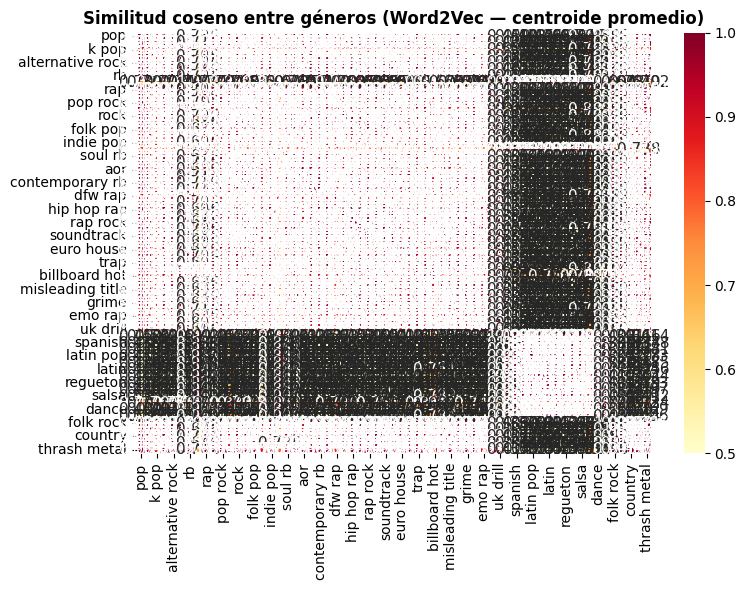


Pares de géneros más similares:
folk rock  country        0.998437
pop        dance pop      0.998249
           rb             0.998104
hip hop    pop rap        0.997651
           rap            0.997484
           hip hop rap    0.997190


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df_sim = analizador_sg.similitud_entre_generos(
    df, col_letra="letra", col_genero="genero"
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_sim, annot=True, fmt=".3f", cmap="YlOrRd",
    vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5,
    annot_kws={"size": 11}
)
ax.set_title("Similitud coseno entre géneros (Word2Vec — centroide promedio)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nPares de géneros más similares:")
sim_upper = df_sim.where(
    __import__("numpy").triu(__import__("numpy").ones(df_sim.shape, dtype=bool), k=1)
).stack().sort_values(ascending=False)
print(sim_upper.head(6).to_string())

## 6. Vocabulario exclusivo por género

In [10]:
import pandas as pd

exclusivo = analizador_sg.vocabulario_exclusivo(
    df, col_letra="letra", col_genero="genero", top_n=15
)

# Mostrar como tabla
max_len = max(len(v) for v in exclusivo.values())
tabla = {}
for genero, palabras in exclusivo.items():
    tabla[genero] = palabras + [""] * (max_len - len(palabras))

df_excl = pd.DataFrame(tabla)
df_excl.index = [f"#{i+1}" for i in range(max_len)]
print("\nPalabras más características por género (exclusividad relativa):")
print(df_excl.to_string())


Vocabulario exclusivo de 'pop':
  ['miłość', 'siedzę', 'powinna', 'celebrowana', 'być', 'الرجاء', 'عينيها', 'في', 'ją', 'poi', 'moja', 'bisa', 'cię', 'jak', 'zwrotka']

Vocabulario exclusivo de 'alternative pop':
  ['corpse', 'flares', 'napalm', 'actual', 'weaker', 'driven', 'articles', 'layers', 'hospital', 'died', 'area', 'symptoms', 'lived', 'oceans', 'awaited']

Vocabulario exclusivo de 'k pop':
  ['폰으로', '어렵지', '눈물이', '것들', '배로', '여기도', '楽しそうなgirl', '是我', '나눠대던', '튀어', '불이', '노랜', '멎었어', '知らないうち', '좋다고']

Vocabulario exclusivo de 'hip hop':
  ['tatort', 'salame', 'fliehen', 'vom', 'isten', 'زۆۆر', 'vehetett', 'jak', 'tátongva', 'üresen', 'نابینەوە', 'bozar', 'نەخێر', 'ilyen', 'jealousi']

Vocabulario exclusivo de 'alternative rock':
  ['myths', 'achilles', 'castles', 'awareness', 'flares', 'threading', 'oléoléolé', 'discovered', 'motivo', 'dooroo', 'testaments', 'در', 'ihe', 'cosas', 'أبي']

Vocabulario exclusivo de 'dance pop':
  ['cabe', 'eras', 'supongo', 'ciega', 'duda', 'deb

## 7. Visualización t-SNE de embeddings de palabras

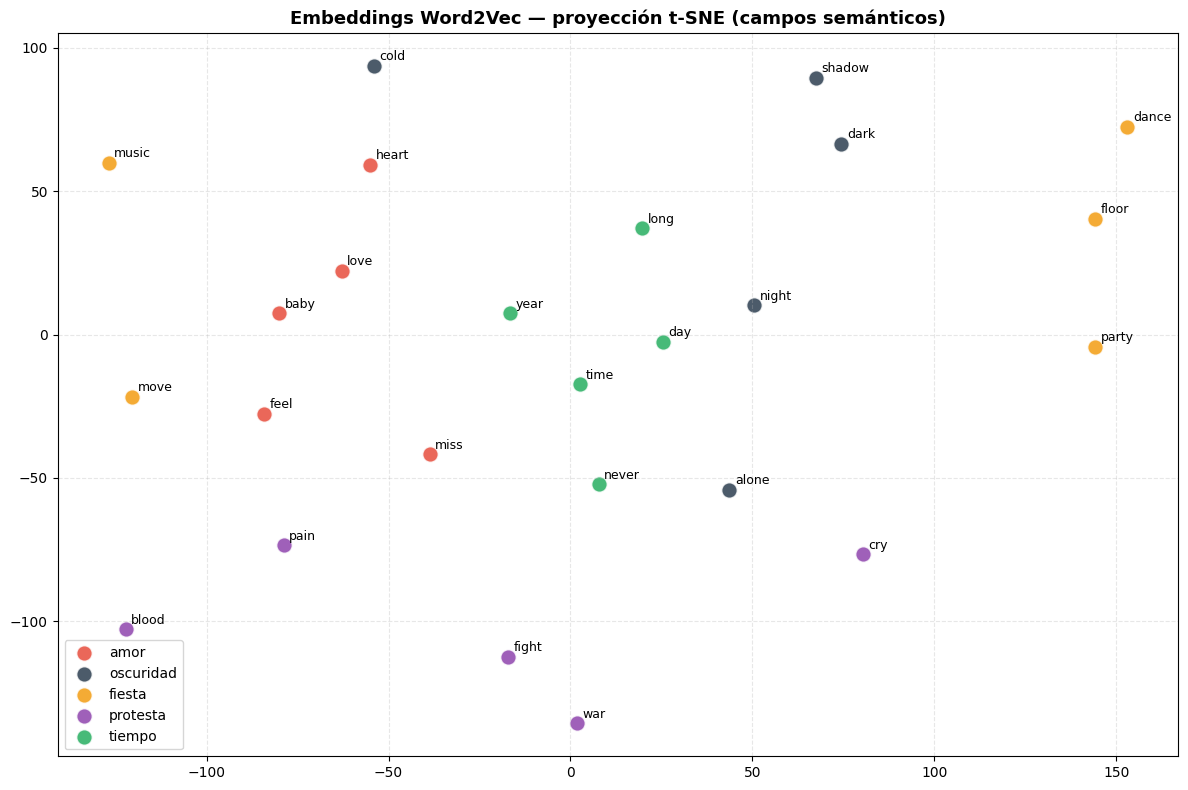

In [11]:
from sklearn.manifold import TSNE
import numpy as np

grupos_palabras = {
    "amor":      ["love", "heart", "feel", "baby", "miss"],
    "oscuridad": ["dark", "night", "shadow", "alone", "cold"],
    "fiesta":    ["dance", "party", "move", "floor", "music"],
    "protesta":  ["fight", "war", "pain", "cry", "blood"],
    "tiempo":    ["time", "day", "year", "long", "never"],
}

colores = {
    "amor": "#e74c3c", "oscuridad": "#2c3e50", "fiesta": "#f39c12",
    "protesta": "#8e44ad", "tiempo": "#27ae60"
}

palabras_list, vectores_list, cats_list = [], [], []
wv = entrenador.modelo_sg.wv

for cat, pals in grupos_palabras.items():
    for p in pals:
        if p in wv:
            palabras_list.append(p)
            vectores_list.append(wv[p])
            cats_list.append(cat)

if len(vectores_list) > 4:
    tsne = TSNE(n_components=2, random_state=42,
                perplexity=min(5, len(vectores_list) - 1))
    v2d = tsne.fit_transform(np.array(vectores_list))

    fig, ax = plt.subplots(figsize=(12, 8))
    for cat in grupos_palabras:
        idx = [i for i, c in enumerate(cats_list) if c == cat]
        ax.scatter(v2d[idx, 0], v2d[idx, 1], c=colores[cat],
                   label=cat, s=130, alpha=0.85, edgecolors="white", linewidth=1.2)
        for i in idx:
            ax.annotate(palabras_list[i], (v2d[i, 0], v2d[i, 1]),
                        fontsize=9, xytext=(4, 4), textcoords="offset points")

    ax.set_title("Embeddings Word2Vec — proyección t-SNE (campos semánticos)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes palabras en el vocabulario para t-SNE.")

## 8. Embeddings de canciones completas (vector promedio)

In [12]:
from src.embeddings.embeddings_w2v import calcular_vector_promedio
import numpy as np

# Calcular vector promedio para cada canción
print("Calculando vectores promedio word2vec para cada canción...")
vectores_canciones = []
wv = entrenador.modelo_sg.wv

for letra in df["letra"].fillna(""):
    vec = calcular_vector_promedio(str(letra), wv)
    vectores_canciones.append(vec if vec else [0.0] * 100)

vectores_array = np.array(vectores_canciones)
print(f"Matriz de embeddings: {vectores_array.shape}")
print(f"  {vectores_array.shape[0]} canciones × {vectores_array.shape[1]} dimensiones")

Calculando vectores promedio word2vec para cada canción...
Matriz de embeddings: (6940, 100)
  6940 canciones × 100 dimensiones


## 9. Actualizar embeddings en MongoDB

In [13]:
from src.embeddings.embeddings_w2v import actualizar_embeddings_mongodb

# Actualiza embeddings.word2vec_avg en cada documento de MongoDB
actualizar_embeddings_mongodb(
    df=df,
    modelo=entrenador.modelo_sg,
    col_id="id",
    col_letra="letra",
    batch_size=100,
)
print("word2vec_avg actualizado correctamente en MongoDB.")

  Actualizados: 100/6940
  Actualizados: 200/6940
  Actualizados: 300/6940
  Actualizados: 400/6940
  Actualizados: 500/6940
  Actualizados: 600/6940
  Actualizados: 700/6940
  Actualizados: 800/6940
  Actualizados: 900/6940
  Actualizados: 1000/6940
  Actualizados: 1100/6940
  Actualizados: 1200/6940
  Actualizados: 1300/6940
  Actualizados: 1400/6940
  Actualizados: 1500/6940
  Actualizados: 1600/6940
  Actualizados: 1700/6940
  Actualizados: 1800/6940
  Actualizados: 1900/6940
  Actualizados: 2000/6940
  Actualizados: 2100/6940
  Actualizados: 2200/6940
  Actualizados: 2300/6940
  Actualizados: 2400/6940
  Actualizados: 2500/6940
  Actualizados: 2600/6940
  Actualizados: 2700/6940
  Actualizados: 2800/6940
  Actualizados: 2900/6940
  Actualizados: 3000/6940
  Actualizados: 3100/6940
  Actualizados: 3200/6940
  Actualizados: 3300/6940
  Actualizados: 3400/6940
  Actualizados: 3500/6940
  Actualizados: 3600/6940
  Actualizados: 3700/6940
  Actualizados: 3800/6940
  Actualizados: 3900/